In [1]:
# If OpenCV is missing/broken, run once in a cell and RESTART the kernel afterwards:
#   %pip install "opencv-python>=4.8,<5"      (OpenCV 5.x has no CascadeClassifier)
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DATA_DIR = "data"   # must contain train/ and test/
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Apple MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.14.1
CUDA available: False
Apple MPS available: True


In [2]:
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    for emotion in sorted(os.listdir(f"{DATA_DIR}/{split}")):
        n = len(os.listdir(f"{DATA_DIR}/{split}/{emotion}"))
        print(f"  {emotion:10s} {n}")


TRAIN
  angry      3995
  disgust    436
  fear       4097
  happy      7215
  neutral    4965
  sad        4830
  surprise   3171

TEST
  angry      958
  disgust    111
  fear       1024
  happy      1774
  neutral    1233
  sad        1247
  surprise   831


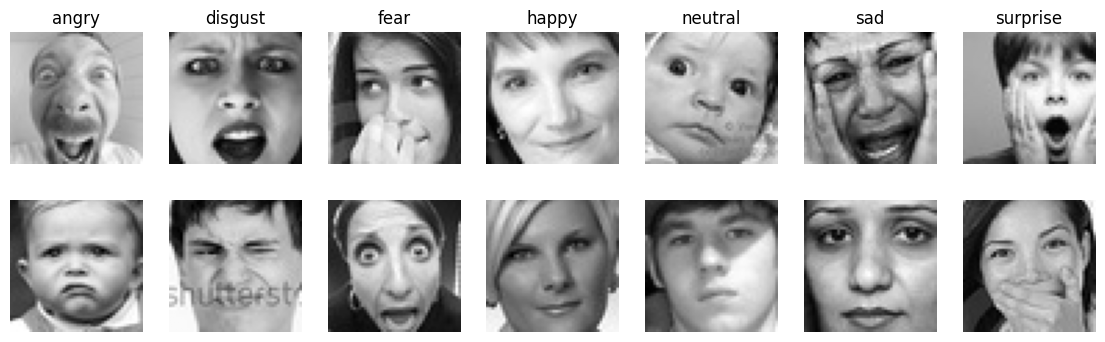

In [3]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for col, emotion in enumerate(sorted(os.listdir(f"{DATA_DIR}/train"))):
    folder = f"{DATA_DIR}/train/{emotion}"
    for row in range(2):
        img = plt.imread(f"{folder}/{os.listdir(folder)[row]}")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(emotion)
plt.show()

In [4]:
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

test_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

In [5]:
train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", train_transform)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test",  test_transform)

print("Classes:", train_ds.classes)
print("Train images:", len(train_ds), "| Test images:", len(test_ds))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

images, labels = next(iter(train_dl))
print("Batch shape:", images.shape)
print("Labels:", labels[:10])

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train images: 28709 | Test images: 7178
Batch shape: torch.Size([64, 1, 48, 48])
Labels: tensor([4, 0, 0, 0, 0, 6, 0, 3, 2, 3])


In [6]:
import torch.nn as nn

def conv_block(cin, cout):
    layers = []
    for i in range(2):
        layers += [
            nn.Conv2d(cin if i == 0 else cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        ]
    layers += [nn.MaxPool2d(2), nn.Dropout(0.25)]
    return nn.Sequential(*layers)

In [7]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [8]:
model = EmotionCNN(num_classes=7)

x = images                      # the batch from Step 5
for i, block in enumerate(model.features):
    x = block(x)
    print(f"After block {i+1}: {tuple(x.shape)}")

out = model(images)
print("Final output:", tuple(out.shape))

total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {total:,}")

After block 1: (64, 32, 24, 24)
After block 2: (64, 64, 12, 12)
After block 3: (64, 128, 6, 6)
After block 4: (64, 256, 3, 3)
Final output: (64, 7)
Trainable parameters: 1,240,231


In [9]:
import math

criterion = nn.CrossEntropyLoss()
model.eval()
with torch.no_grad():
    logits = model(images)
    loss = criterion(logits, labels)

print(f"Loss of untrained model: {loss.item():.3f}")
print(f"Expected if guessing randomly: {math.log(7):.3f}")

Loss of untrained model: 1.960
Expected if guessing randomly: 1.946


In [10]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():   # Apple Silicon GPU (much faster than CPU on a Mac)
    device = "mps"
else:
    device = "cpu"
print("Using:", device)

model = EmotionCNN(num_classes=7).to(device)

counts = torch.bincount(torch.tensor(train_ds.targets)).float()
weights = (counts.sum() / (len(counts) * counts)).to(device)
print("Class weights:", dict(zip(train_ds.classes, weights.cpu().numpy().round(2))))

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Using: mps
Class weights: {'angry': np.float32(1.03), 'disgust': np.float32(9.41), 'fear': np.float32(1.0), 'happy': np.float32(0.57), 'neutral': np.float32(0.83), 'sad': np.float32(0.85), 'surprise': np.float32(1.29)}


In [11]:
def evaluate(model, loader):
    model.eval()                    # turns off dropout, uses fixed BatchNorm stats
    correct, total = 0, 0
    with torch.no_grad():           # no gradients needed, saves memory and time
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)   # index of highest score
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [12]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()           # clear old gradients
        loss = criterion(model(x), y)   # forward pass + loss
        loss.backward()                 # compute gradients
        optimizer.step()                # update weights

        running_loss += loss.item() * y.size(0)
    return running_loss / len(loader.dataset)

In [13]:
import time

model.train()
start = time.time()
for i, (x, y) in enumerate(train_dl):
    if i == 10:
        break
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    criterion(model(x), y).backward()
    optimizer.step()

per_batch = (time.time() - start) / 10
print(f"{per_batch:.2f}s per batch -> about {per_batch * len(train_dl) / 60:.1f} min per epoch")


0.54s per batch -> about 4.1 min per epoch


In [14]:
EPOCHS = 20
MAX_LR = 2e-3

model = EmotionCNN(num_classes=7).to(device)   # start from scratch
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, epochs=EPOCHS, steps_per_epoch=len(train_dl)
)

In [15]:
# Non-augmented view of the training set, so train accuracy is comparable to test accuracy
train_eval_dl = DataLoader(datasets.ImageFolder(f"{DATA_DIR}/train", test_transform),
                           batch_size=128, shuffle=False)

history = {"loss": [], "train_acc": [], "test_acc": [], "lr": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        scheduler.step()                  # update learning rate every batch
        running_loss += loss.item() * y.size(0)

    epoch_loss = running_loss / len(train_ds)
    train_acc = evaluate(model, train_eval_dl)  # no augmentation; shows the overfitting gap
    test_acc = evaluate(model, test_dl)
    lr_now = optimizer.param_groups[0]["lr"]

    history["loss"].append(epoch_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["lr"].append(lr_now)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({"state_dict": model.state_dict(), "classes": train_ds.classes},
                   "emotion_torch.pt")
        marker = " <- saved"
    else:
        marker = ""

    print(f"Epoch {epoch:2d}/{EPOCHS} | loss {epoch_loss:.3f} | "
          f"train {train_acc:.1%} | test {test_acc:.1%} | "
          f"lr {lr_now:.5f} | {time.time()-t0:.0f}s{marker}")

print(f"\nBest test accuracy: {best_acc:.1%}")

Epoch  1/20 | loss 2.030 | train 19.7% | test 18.9% | lr 0.00021 | 35s <- saved
Epoch  2/20 | loss 1.902 | train 34.1% | test 34.0% | lr 0.00056 | 31s <- saved
Epoch  3/20 | loss 1.750 | train 39.4% | test 41.0% | lr 0.00104 | 30s <- saved
Epoch  4/20 | loss 1.688 | train 50.9% | test 50.8% | lr 0.00152 | 30s <- saved
Epoch  5/20 | loss 1.636 | train 51.1% | test 50.9% | lr 0.00187 | 30s <- saved
Epoch  6/20 | loss 1.602 | train 40.6% | test 41.5% | lr 0.00200 | 30s
Epoch  7/20 | loss 1.559 | train 49.9% | test 49.5% | lr 0.00197 | 32s
Epoch  8/20 | loss 1.528 | train 55.8% | test 55.0% | lr 0.00190 | 32s <- saved
Epoch  9/20 | loss 1.490 | train 58.2% | test 56.3% | lr 0.00178 | 33s <- saved
Epoch 10/20 | loss 1.461 | train 60.3% | test 58.0% | lr 0.00162 | 34s <- saved
Epoch 11/20 | loss 1.438 | train 60.0% | test 58.2% | lr 0.00143 | 34s <- saved
Epoch 12/20 | loss 1.403 | train 60.3% | test 58.3% | lr 0.00122 | 33s <- saved
Epoch 13/20 | loss 1.384 | train 61.3% | test 59.0% | lr 0

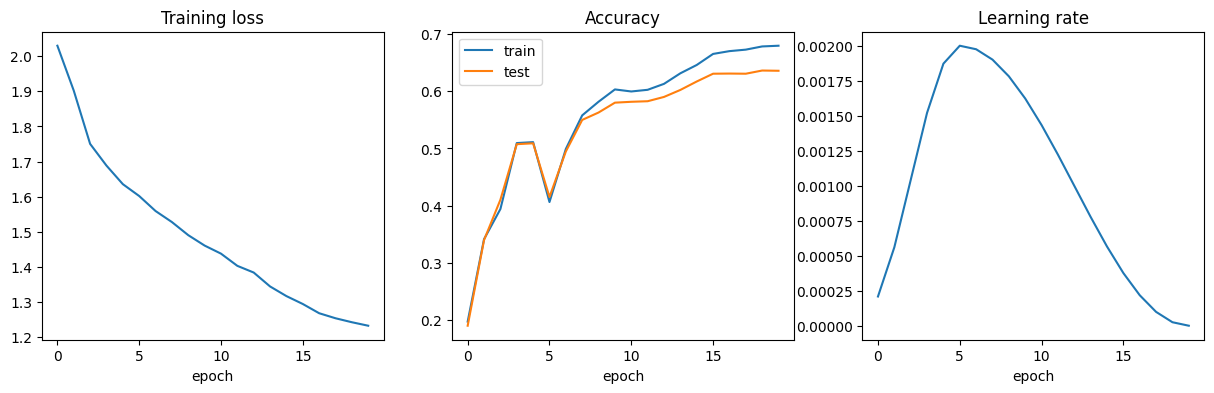

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(history["loss"]); ax[0].set_title("Training loss")
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["test_acc"], label="test")
ax[1].set_title("Accuracy"); ax[1].legend()
ax[2].plot(history["lr"]); ax[2].set_title("Learning rate")

for a in ax: a.set_xlabel("epoch")
plt.show()

In [17]:
ckpt = torch.load("emotion_torch.pt", map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for x, y in test_dl:
        probs = torch.softmax(model(x.to(device)), dim=1).cpu()
        all_probs.append(probs)
        all_preds.append(probs.argmax(1))
        all_labels.append(y)

all_probs = torch.cat(all_probs)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Accuracy: {(all_preds == all_labels).float().mean():.1%}")

Accuracy: 63.7%


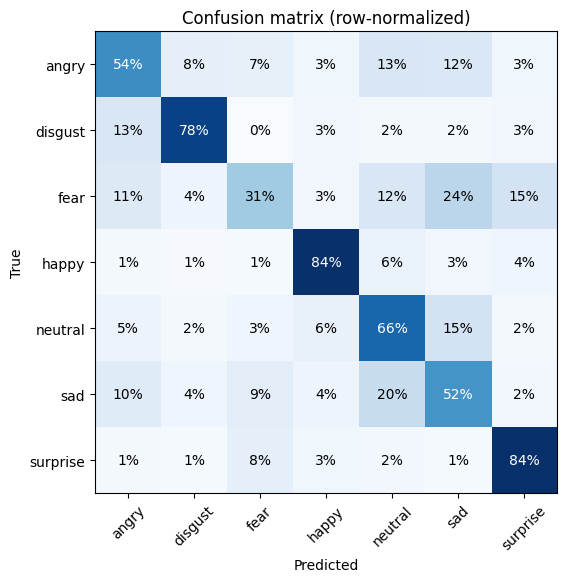

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

classes = train_ds.classes
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)    # each row sums to 100%

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm_norm, cmap="Blues")
ax.set_xticks(range(7)); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks(range(7)); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_norm[i, j]:.0%}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black")
plt.title("Confusion matrix (row-normalized)")
plt.show()

In [19]:
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

              precision    recall  f1-score   support

       angry      0.603     0.540     0.570       958
     disgust      0.291     0.784     0.424       111
        fear      0.511     0.308     0.384      1024
       happy      0.872     0.840     0.856      1774
     neutral      0.571     0.664     0.614      1233
         sad      0.513     0.518     0.515      1247
    surprise      0.693     0.836     0.758       831

    accuracy                          0.637      7178
   macro avg      0.579     0.641     0.589      7178
weighted avg      0.641     0.637     0.632      7178



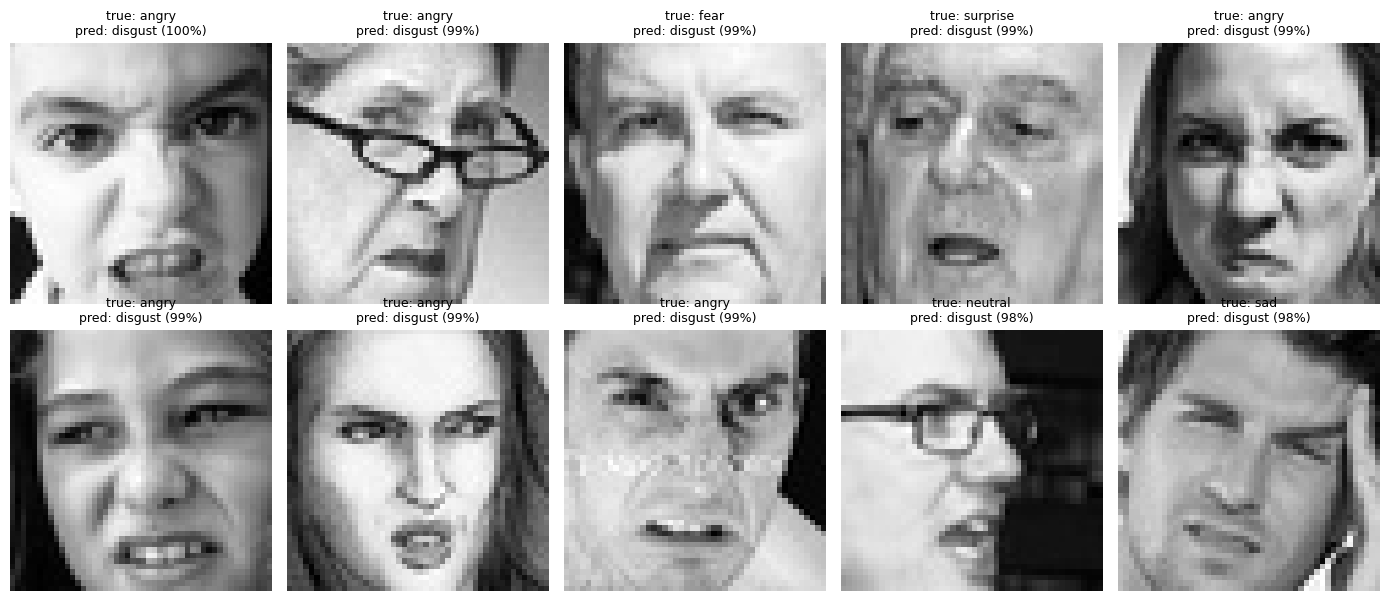

In [20]:
wrong = (all_preds != all_labels).nonzero().squeeze()
confidence = all_probs[wrong].max(dim=1).values
worst = wrong[confidence.argsort(descending=True)[:10]]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flat, worst):
    img, _ = test_ds[idx.item()]
    ax.imshow(img.squeeze() * 0.5 + 0.5, cmap="gray")    # undo Normalize
    ax.set_title(f"true: {classes[all_labels[idx]]}\n"
                 f"pred: {classes[all_preds[idx]]} ({all_probs[idx].max():.0%})",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [21]:
pairs = [(cm_norm[i, j], classes[i], classes[j])
         for i in range(7) for j in range(7) if i != j]
for v, true, pred in sorted(pairs, reverse=True)[:6]:
    print(f"{true:9s} -> predicted as {pred:9s} {v:.0%}")

fear      -> predicted as sad       24%
sad       -> predicted as neutral   20%
fear      -> predicted as surprise  15%
neutral   -> predicted as sad       15%
angry     -> predicted as neutral   13%
disgust   -> predicted as angry     13%


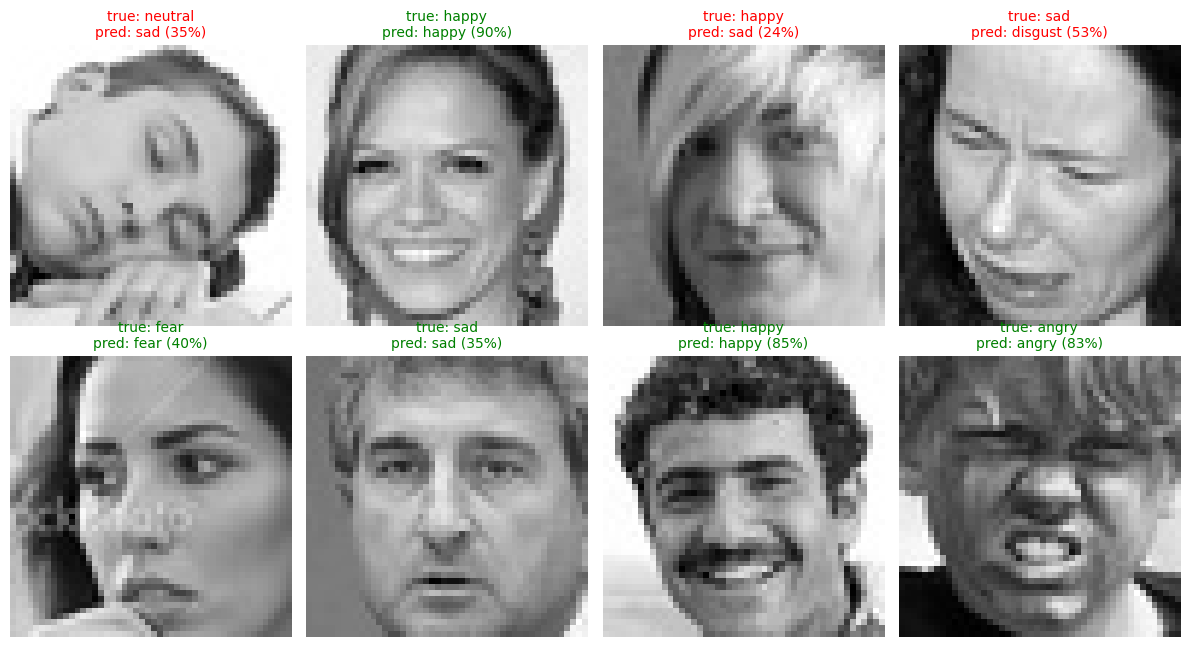

In [22]:
import numpy as np
import cv2
from PIL import Image

def predict_face(gray):
    """gray: raw 2-D uint8 grayscale image (any size). Returns a numpy array of 7 class probabilities."""
    tensor = test_transform(Image.fromarray(gray)).unsqueeze(0).to(device)   # same preprocessing as the test set
    model.eval()
    with torch.no_grad():
        return torch.softmax(model(tensor), dim=1).squeeze(0).cpu().numpy()

import random

samples = random.sample(test_ds.samples, 8)    # list of (file_path, label_index)

fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for ax, (path, label) in zip(axes.flat, samples):
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # load raw pixels, no transforms
    probs = predict_face(gray)
    pred = probs.argmax()
    ax.imshow(gray, cmap="gray"); ax.axis("off")
    ax.set_title(f"true: {classes[label]}\npred: {classes[pred]} ({probs[pred]:.0%})",
                 color="green" if pred == label else "red", fontsize=10)
plt.tight_layout()
plt.show()

Faces found: 1


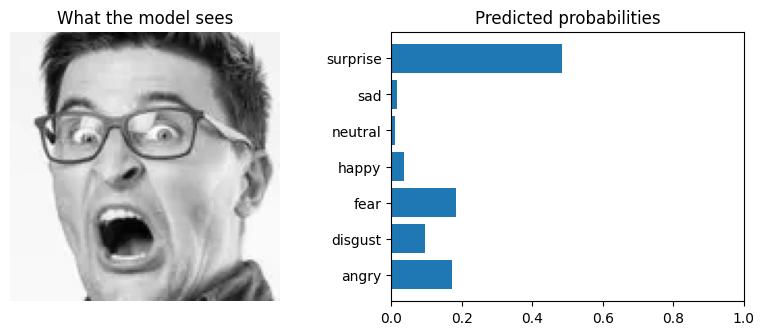

In [23]:
import os
import cv2

IMAGE_PATH = "my_photo.jpg"        # <- change to a real photo of a face

assert hasattr(cv2, "CascadeClassifier"), (
    f"OpenCV {cv2.__version__} has no CascadeClassifier. Run: %pip install \"opencv-python>=4.8,<5\" and restart the kernel.")
if not os.path.exists(IMAGE_PATH):
    print(f"'{IMAGE_PATH}' not found in {os.getcwd()}. Put a photo there or change IMAGE_PATH.")
else:
    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    img = cv2.imread(IMAGE_PATH)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(60, 60))
    print("Faces found:", len(faces))

    if len(faces) == 0:
        print("No face detected - try a clearer, front-facing, well-lit photo.")
    else:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])    # use the largest face
        crop = gray[y:y+h, x:x+w]
        probs = predict_face(crop)

        fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
        ax[0].imshow(crop, cmap="gray"); ax[0].axis("off"); ax[0].set_title("What the model sees")
        ax[1].barh(classes, probs); ax[1].set_xlim(0, 1); ax[1].set_title("Predicted probabilities")
        plt.show()